# Forecast Using the TabPFN Family


foundationforecast ships a single `TabPFN` class that supports TabPFN-2 (default) and TabPFN-3 checkpoints. Pass `model_path` to select the checkpoint:

| Version | `model_path` | Notes |
|---------|-------------|-------|
| **TabPFN-2** (default) | `tabpfn-v2-regressor-2noar4o2.ckpt` | TabPFN NC license |
| **TabPFN-3** | `tabpfn-v3-regressor-v3_20260506_timeseries.ckpt` | Finetuned TS checkpoint; TabPFN NC license; LOCAL only |

*Requirements*:

    - Python 3.10 – 3.12
    - LOCAL mode (default when CUDA is available): accept terms at [ux.priorlabs.ai](https://ux.priorlabs.ai) and set `TABPFN_TOKEN`
    - TabPFN-3 recommends `context_length=32768`; TabPFN-2 defaults to 4096

**License:** TabPFN-2.6+ and TabPFN-3 weights use the TabPFN Non-Commercial license. Commercial production requires a [Prior Labs license or API](https://docs.priorlabs.ai/models).

In this example we compare TabPFN-2 and TabPFN-3 on event pageview data.


## Import libraries


In [1]:
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

from foundationforecast import FoundationForecast

load_dotenv(Path(".env"))

if sys.version_info >= (3, 13):
    raise RuntimeError("TabPFN requires Python < 3.13")


/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)


In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data


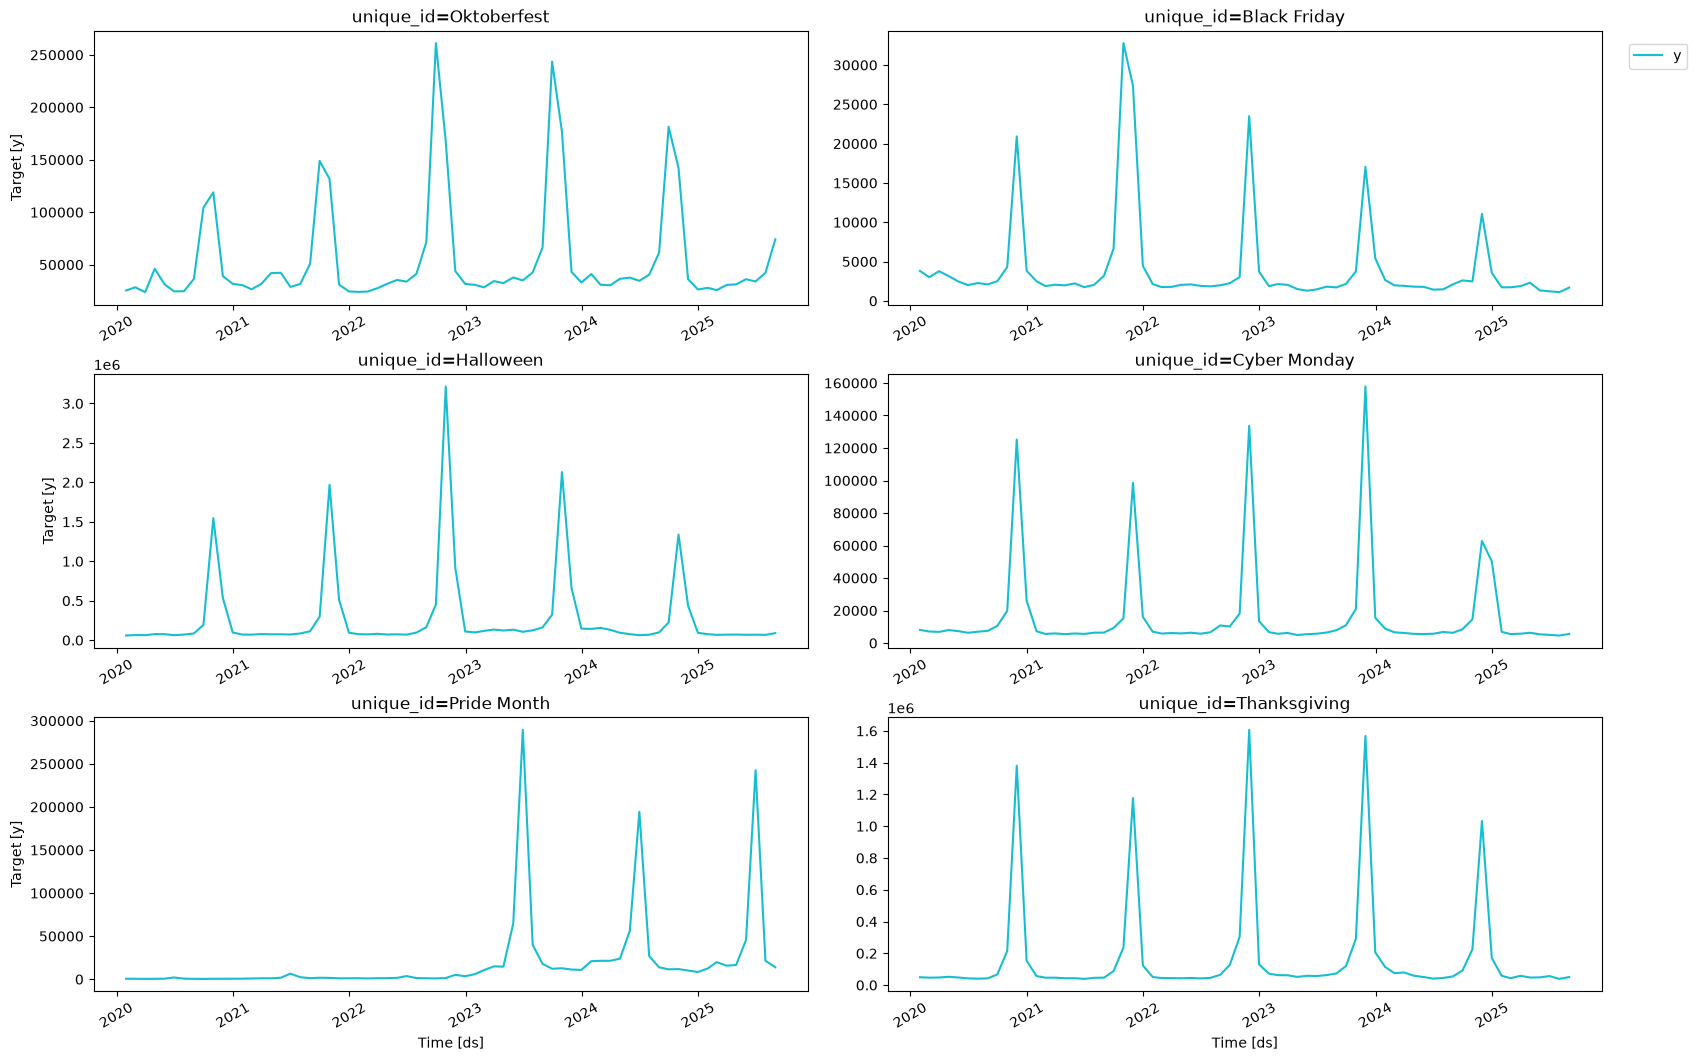

In [3]:
FoundationForecast.plot(df)


## Import the models


In [4]:
from tabpfn_time_series import TabPFNMode

from foundationforecast.models.tabpfn import TABPFN_V2_MODEL, TABPFN_V3_MODEL, TabPFN


## Create a FoundationForecast

We compare TabPFN-2 with TabPFN-3 in LOCAL mode. Each model gets a distinct `alias`.


In [5]:
models = [
    TabPFN(
        model_path=TABPFN_V2_MODEL,
        mode=TabPFNMode.LOCAL,
        alias="TabPFN-2",
    ),
    TabPFN(
        model_path=TABPFN_V3_MODEL,
        mode=TabPFNMode.LOCAL,
        context_length=32768,
        alias="TabPFN-3",
    ),
]

ff = FoundationForecast(models=models)


## Generate forecast

TabPFN outputs nine fixed quantiles (0.1 through 0.9). Pass `level=[20, 40, 60, 80]` for standard decile intervals, or any `level` / `quantiles` (interpolated from native knots with edge clamping).


In [6]:
level = [70, 80, 90]
cv_df = ff.cross_validation(df=df, h=12, freq="MS", level=level)


Predicting time series: 100%|██████████| 6/6 [00:00<00:00, 69.95it/s]
1it [00:51, 51.37s/it]
Predicting time series: 100%|██████████| 6/6 [00:00<00:00, 968.70it/s]
1it [01:05, 65.07s/it]


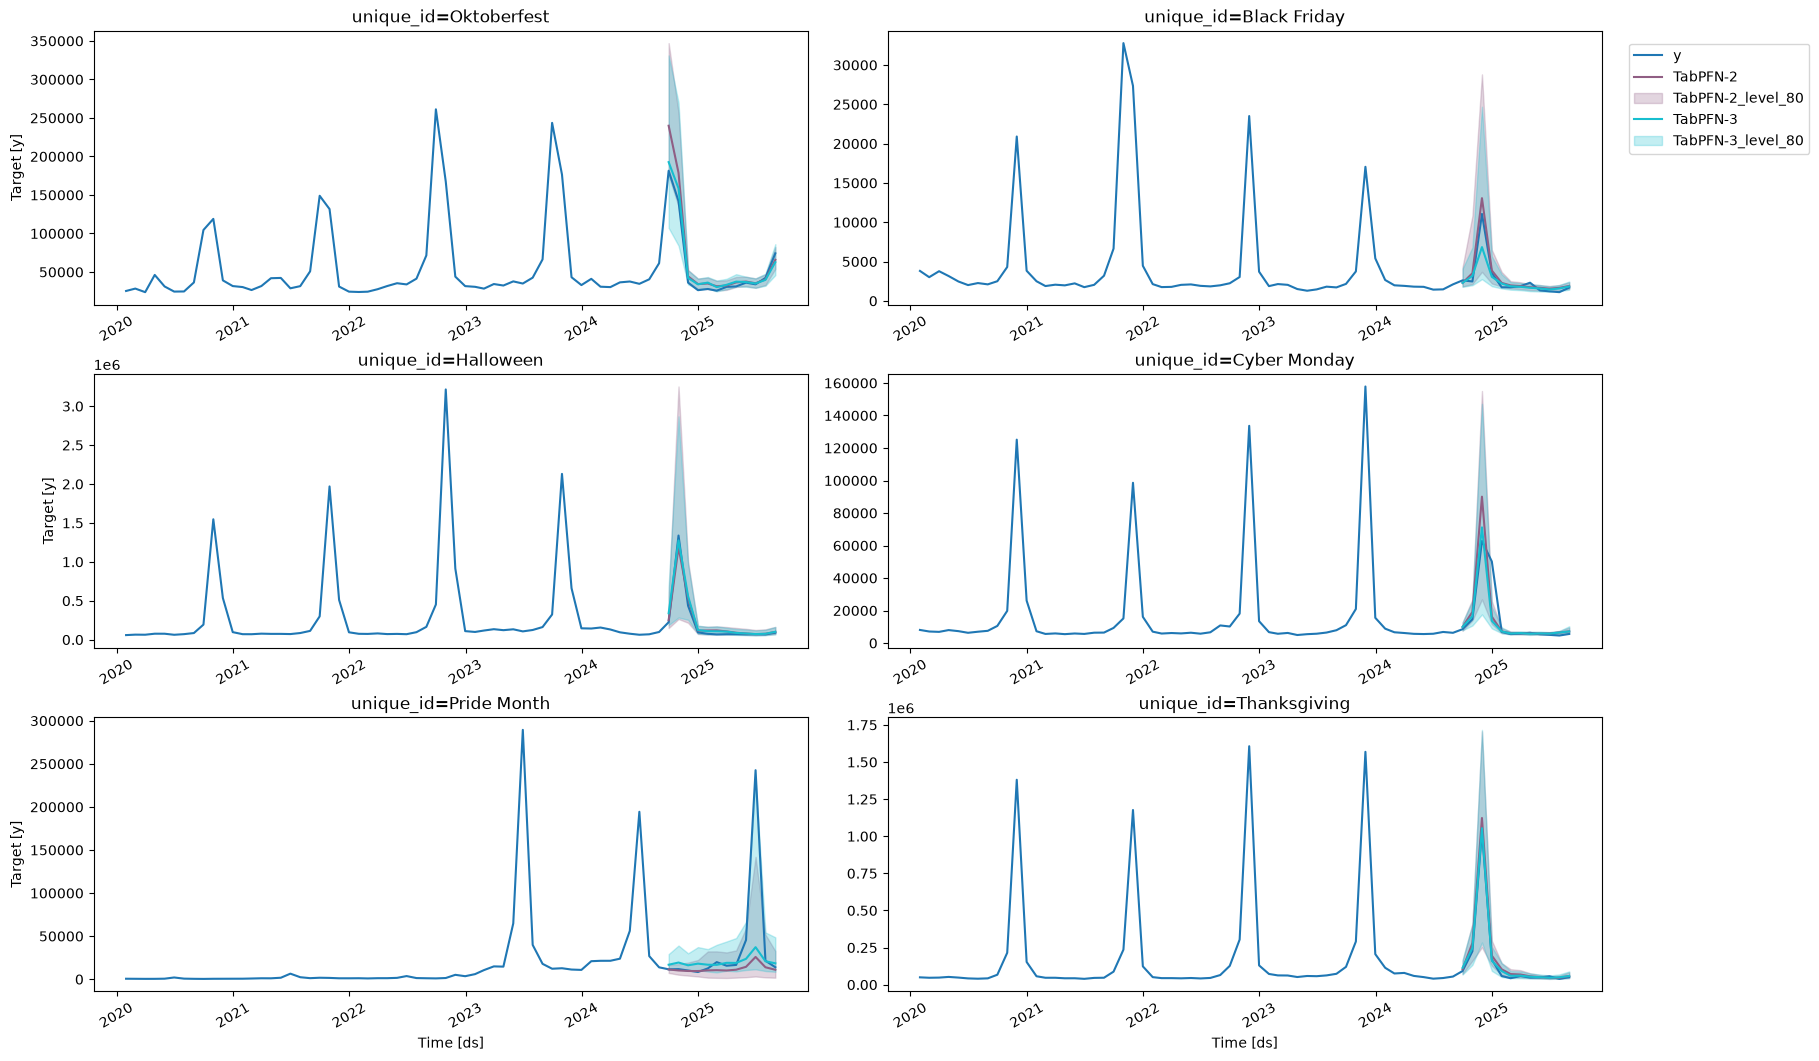

In [7]:
ff.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [8]:
cv_df.head()


,unique_id,ds,cutoff,y,TabPFN-2,TabPFN-2-lo-70,TabPFN-2-hi-70,TabPFN-2-lo-80,TabPFN-2-hi-80,TabPFN-2-lo-90,TabPFN-2-hi-90,TabPFN-3,TabPFN-3-lo-70,TabPFN-3-hi-70,TabPFN-3-lo-80,TabPFN-3-hi-80,TabPFN-3-lo-90,TabPFN-3-hi-90
0,Black Friday,2024-09-30,2024-09-01,2607,2280.421875,1904.609802,3661.744873,1835.111816,4280.912109,1835.111816,4280.912109,2288.188477,1860.842346,3647.810303,1790.558838,4088.011475,1790.558838,4088.011475
1,Black Friday,2024-10-31,2024-09-01,2470,3518.327637,2308.022339,8394.845215,2143.404785,10811.257812,2143.404785,10811.257812,3177.973389,2126.817139,5839.692871,1994.401367,6797.868652,1994.401367,6797.868652
2,Black Friday,2024-11-30,2024-09-01,11058,13064.052734,4465.765991,26366.203125,3694.268311,28813.093750,3694.268311,28813.093750,6840.537598,3119.724121,22256.286133,2764.262939,24692.289062,2764.262939,24692.289062
3,Black Friday,2024-12-31,2024-09-01,3548,3865.438965,2418.656860,5876.590088,2215.349121,6496.193848,2215.349121,6496.193848,3062.548584,1993.716858,5083.141602,1865.932739,5671.841797,1865.932739,5671.841797
4,Black Friday,2025-01-31,2024-09-01,1724,2284.928711,1881.243774,3318.222900,1812.089233,3675.161377,1812.089233,3675.161377,2199.708252,1681.754517,3118.110596,1586.586914,3385.278320,1586.586914,3385.278320


## Evaluation


In [9]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)


metric,mase,scaled_crps
TabPFN-3,0.785,0.155
TabPFN-2,1.020,0.184
